In [51]:
#  LOAN APPROVAL PREDICTION SYSTEM
!pip install pandas numpy matplotlib seaborn scikit-learn gradio joblib -q


# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
import joblib
import gradio as gr
import plotly.express as px
import ipywidgets as widgets
from google.colab import output
output.enable_custom_widget_manager()
from IPython.display import display


In [52]:
# ================================
#  LOAD AND DISPLAY FULL DATASET
# ================================
FILE = "loan prediction dataset.csv"
df = pd.read_csv(FILE)
print(" Dataset Loaded Successfully!")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df)

print("\n--- DATA INFO ---")
print(df.info())

print("\n--- MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())

# ================================
# DATA CLEANING & FEATURE SETUP
# ================================
eda = df.copy()
eda['Loan_Status_num'] = eda['Loan_Status'].map({'Y': 1, 'N': 0})

numeric_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount',
                'Loan_Amount_Term','Credit_History']
categorical_cols = ['Gender','Married','Dependents',
                    'Education','Self_Employed','Property_Area']
target_col = 'Loan_Status'

df = df[df[target_col].isin(['Y','N'])].copy()
print(" Data cleaning completed successfully.")


 Dataset Loaded Successfully!


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.000000,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.000000,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.000000,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.000000,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.000000,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.000000,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.000000,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.000000,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.000000,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.000000,349.0,360.0,1.0,Semiurban,N



--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None

--- MISSING VALUES PER COLUMN ---
Loan_ID               0
Gender               13
Marri

In [53]:
# ================================
#  TRAIN / TEST SPLIT
# ================================
X = df[numeric_cols + categorical_cols]
y = df[target_col].map({'Y':1,'N':0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train-test split done successfully.")

# ================================
#  PREPROCESSING PIPELINE
# ================================
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

print("Preprocessing pipeline ready.")


Train-test split done successfully.
Preprocessing pipeline ready.



Logistic Regression Accuracy: 86.18%
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



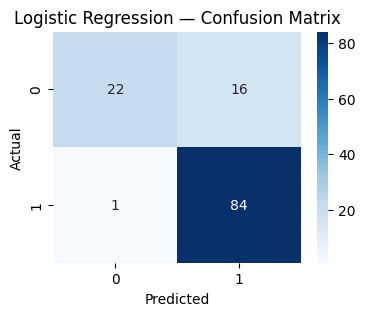


Decision Tree Accuracy: 75.61%
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.61      0.61        38
           1       0.82      0.82      0.82        85

    accuracy                           0.76       123
   macro avg       0.71      0.71      0.71       123
weighted avg       0.76      0.76      0.76       123



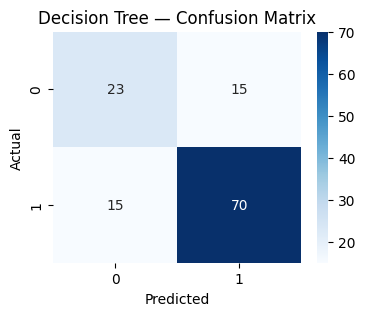


Random Forest Accuracy: 82.11%
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.61      0.68        38
           1       0.84      0.92      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.76      0.78       123
weighted avg       0.82      0.82      0.81       123



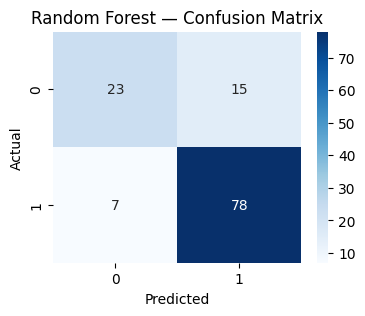


Best Model: Logistic Regression (86.18% Accuracy)


In [54]:
# ================================
#  MULTI-MODEL TRAINING + CONFUSION MATRIX
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42)
}

results = {}

def evaluate(model, name):
    """Print accuracy, classification report & show confusion matrix."""
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name} Accuracy: {acc*100:.2f}%")
    print("Classification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Train + Evaluate all models
for name, model in models.items():
    clf = Pipeline([('prep', preprocess), ('model', model)])
    clf.fit(X_train, y_train)

    # store accuracy
    acc = accuracy_score(y_test, clf.predict(X_test))
    results[name] = acc

    # full evaluation for each model
    evaluate(clf, name)

# Print best model
best_model_name = max(results, key=results.get)
print(f"\nBest Model: {best_model_name} ({results[best_model_name]*100:.2f}% Accuracy)")


/tmp/ipython-input-3211056637.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




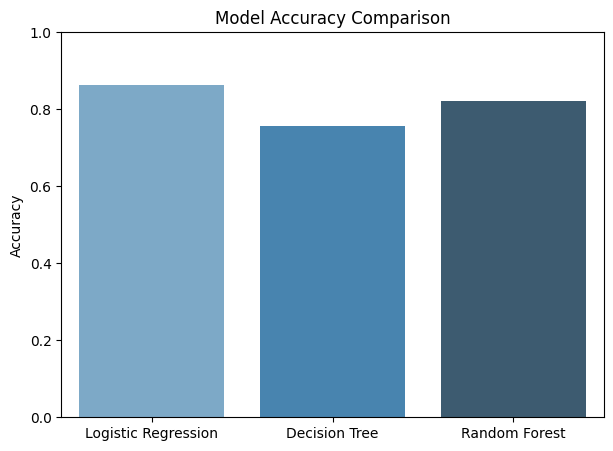

 Best Performing Model: Logistic Regression


In [55]:
plt.figure(figsize=(7,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="Blues_d")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

best_model_name = max(results, key=results.get)
print(f" Best Performing Model: {best_model_name}")


Final model trained.


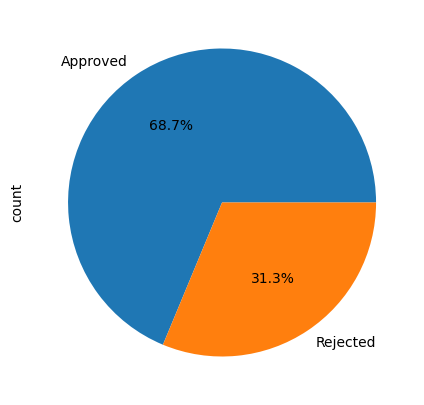

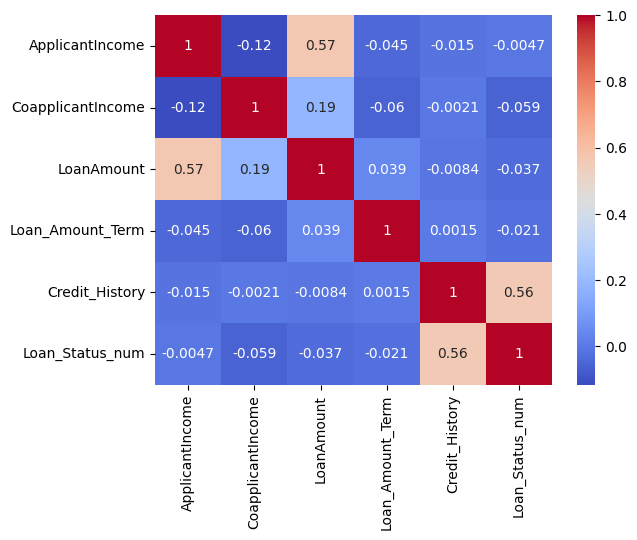

In [56]:
# ================================
# TRAIN FINAL MODEL
# ================================
best_model = Pipeline([
    ('prep', preprocess),
    ('model', models[best_model_name])
])
best_model.fit(X_train, y_train)
print("Final model trained.")

# ================================
# PIE CHART
# ================================
df[target_col].value_counts().rename(
    {'Y':'Approved','N':'Rejected'}
).plot.pie(autopct='%1.1f%%', figsize=(5,5))
plt.show()

# ================================
# HEATMAP
# ================================
sns.heatmap(eda.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


In [57]:
joblib.dump(best_model, "loan_model.pkl")
print("Model saved")


Model saved


In [58]:
# ================================
#  GRADIO INTERFACE (FINAL + RISK LEVEL IN BLACK + REASONS)
# ================================
import gradio as gr
import pandas as pd
import joblib

# Load saved model pipeline
best_model = joblib.load("loan_model.pkl")
best_model_name = "Logistic Regression"

# -------------------------------
#  Prediction Function (with reasons + risk level in BLACK)
# -------------------------------
def predict_loan(Gender, Married, Dependents, Education, Self_Employed,
                 ApplicantIncome, CoapplicantIncome, LoanAmount,
                 Loan_Amount_Term, Credit_History, Property_Area):

    try:
        # 1. Convert input to DataFrame
        data = {
            "ApplicantIncome": float(ApplicantIncome),
            "CoapplicantIncome": float(CoapplicantIncome),
            "LoanAmount": float(LoanAmount),
            "Loan_Amount_Term": float(Loan_Amount_Term),
            "Credit_History": float(Credit_History),
            "Gender": Gender,
            "Married": Married,
            "Dependents": Dependents,
            "Education": Education,
            "Self_Employed": Self_Employed,
            "Property_Area": Property_Area,
        }
        X_in = pd.DataFrame([data])

        # 2. Predict class + probability
        probs = best_model.predict_proba(X_in)[0]
        approve_prob = float(probs[1]) * 100
        pred = int(best_model.predict(X_in)[0])   # 1 = approve, 0 = reject

        # -----------------------------------
        # 3. Risk Classification (BLACK COLOR NOW)
        # -----------------------------------
        if approve_prob >= 75:
            risk = "Low Risk"
        elif approve_prob >= 40:
            risk = "Medium Risk"
        else:
            risk = "High Risk"

        # -----------------------------------
        # 4. Detailed Reasons
        # -----------------------------------
        reasons = []

        if float(Credit_History) == 1:
            reasons.append("✔ Good credit history – indicates responsible repayment behaviour.")
        else:
            reasons.append("✖ Poor credit history – increases chance of default.")

        total_income = float(ApplicantIncome) + float(CoapplicantIncome)
        if total_income >= 5000:
            reasons.append("✔ Sufficient combined monthly income for EMI repayment.")
        else:
            reasons.append("✖ Low income compared to loan amount.")

        if float(LoanAmount) <= 200000:
            reasons.append("✔ Loan amount is within a manageable range.")
        else:
            reasons.append("✖ Loan amount is too high relative to income.")

        if Property_Area in ["Urban", "Semiurban"]:
            reasons.append(f"✔ Property location ({Property_Area}) is favourable and has strong collateral value.")
        else:
            reasons.append("✖ Rural area – lower collateral value.")

        if Education == "Graduate":
            reasons.append("✔ Graduate applicant – usually stable career prospects.")
        else:
            reasons.append("✖ Non-graduate applicants may have less stable income.")

        if Self_Employed == "No":
            reasons.append("✔ Salaried employment – income is more predictable.")
        else:
            reasons.append("✖ Self-employed – income may fluctuate.")

        reasons_html = "<br>".join(reasons)

        # -----------------------------------
        # 5. Build Final HTML Card
        # -----------------------------------
        if pred == 1:
            status_title = "Loan Approved ✅"
            bg = "#E8F5E9"
            border = "#4CAF50"
            text_color = "#1B5E20"
        else:
            status_title = "Loan Rejected ❌"
            bg = "#FFEBEE"
            border = "#EF5350"
            text_color = "#B71C1C"

        # RISK LEVEL TEXT ALWAYS BLACK NOW
        risk_html = f"<span style='font-size:18px; color:black;'><b>Risk Level: {risk}</b></span>"

        html = f"""
        <div style='background-color:{bg};
                    color:{text_color};
                    font-size:20px;
                    font-weight:bold;
                    padding:20px;
                    border-radius:10px;
                    text-align:center;
                    border:2px solid {border};
                    box-shadow:0 3px 7px rgba(0,0,0,0.2);'>

            {status_title}<br>

            <span style='font-size:18px; color:{text_color};'>
                Confidence: {approve_prob:.2f}%
            </span><br>

            {risk_html}

            <hr style='border:1px solid #ddd; margin-top:12px; margin-bottom:12px;'>

            <div style='font-size:16px; text-align:left; color:black;'>
                <b>Reasons for this decision:</b><br><br>
                {reasons_html}
            </div>
        </div>
        """

        return html

    except Exception as e:
        return f"<div style='color:red; font-weight:bold;'>Error: {str(e)}</div>"


# -------------------------------
#  Custom CSS
# -------------------------------
custom_css = """
#predict-button {
    background-color: #1976D2 !important;
    color: white !important;
    border-radius: 8px;
    font-weight: bold;
    height: 45px;
    font-size: 16px;
}
"""

# -------------------------------
#  Build Gradio UI
# -------------------------------
with gr.Blocks(css=custom_css, title="Loan Approval Prediction System") as demo:

    gr.Markdown("""
    <h1 style='text-align:center; color:#0D47A1;'>Loan Approval Prediction System</h1>
    <p style='text-align:center; color:#333; font-size:16px;'>
        Model Used: <b style='color:#00C853;'>Logistic Regression</b>
    </p>
    """)

    with gr.Column():
        Gender = gr.Dropdown(["Male", "Female"], label="Gender", value="Male")
        Married = gr.Dropdown(["Yes", "No"], label="Married", value="Yes")
        Dependents = gr.Dropdown(["0", "1", "2", "3+"], label="Dependents", value="0")
        Education = gr.Dropdown(["Graduate", "Not Graduate"], label="Education", value="Graduate")
        Self_Employed = gr.Dropdown(["Yes", "No"], label="Self Employed", value="No")
        ApplicantIncome = gr.Number(label="Applicant Income (₹)", value=5000)
        CoapplicantIncome = gr.Number(label="Coapplicant Income (₹)", value=2000)
        LoanAmount = gr.Number(label="Loan Amount (₹)", value=150000)
        Loan_Amount_Term = gr.Dropdown(["360", "180", "120", "60"], label="Loan Term (months)", value="360")
        Credit_History = gr.Dropdown(["1", "0"], label="Credit History", value="1")
        Property_Area = gr.Dropdown(["Urban", "Semiurban", "Rural"], label="Property Area", value="Urban")

    predict_button = gr.Button("Check Loan Status", elem_id="predict-button")
    result_html = gr.HTML(label="Prediction Result")

    predict_button.click(
        fn=predict_loan,
        inputs=[Gender, Married, Dependents, Education, Self_Employed,
                ApplicantIncome, CoapplicantIncome, LoanAmount,
                Loan_Amount_Term, Credit_History, Property_Area],
        outputs=result_html,
    )

    gr.HTML("<p style='text-align:center; color:#90A4AE; font-size:12px;'>Developed by Shruti & Team | Cummins College | 2025</p>")

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://64ef8bab0d421a503d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [59]:
# Create synthetic dashboard dataset
np.random.seed(42)
n = 500

dash_df = pd.DataFrame({
    "age": np.random.randint(20, 60, n),
    "income": np.random.randint(20000, 150000, n),
    "loan_amount": np.random.randint(5000, 50000, n),
    "credit_score": np.random.randint(300, 900, n),
    "employment_years": np.random.randint(0, 20, n),
    "married": np.random.choice([0, 1], n),
    "education_level": np.random.choice([1, 2, 3], n),
    "previous_loans": np.random.randint(0, 5, n),
})

dash_df["loan_approved"] = (
    (dash_df["income"] > 40000) &
    (dash_df["credit_score"] > 600) &
    (dash_df["loan_amount"] < 30000)
).astype(int)

# Dashboard Widget
dropdown = widgets.Dropdown(
    options=dash_df.columns[:-1],
    value="income",
    description="Feature:"
)

def update_plot(feature):
    fig = px.histogram(dash_df, x=feature, color="loan_approved",
                       title=f"Distribution of {feature}")
    fig.show()

out = widgets.interactive_output(update_plot, {"feature": dropdown})
display(dropdown, out)


Dropdown(description='Feature:', index=1, options=('age', 'income', 'loan_amount', 'credit_score', 'employment…

Output()

Loan_Status     N    Y
Property_Area         
Rural          69  110
Semiurban      54  179
Urban          69  133


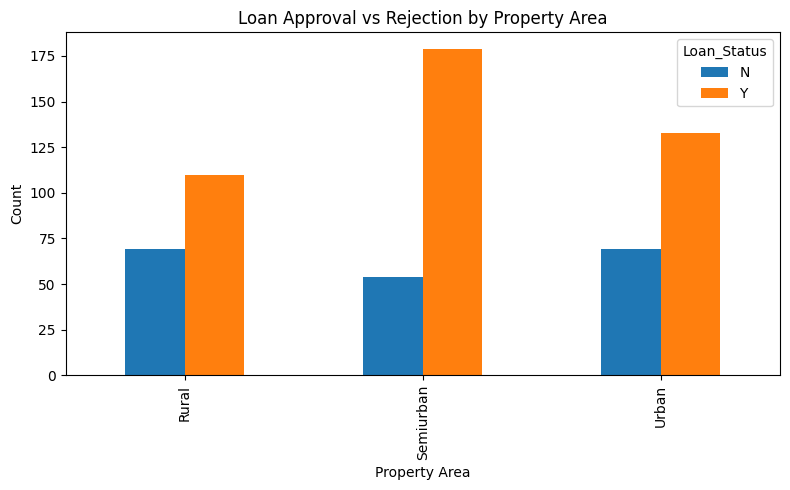

In [60]:
import matplotlib.pyplot as plt

# Count approvals (Y) & rejections (N) for each area
area_status = df.groupby(['Property_Area', 'Loan_Status']).size().reset_index(name='Count')

# Pivot for cleaner plotting
pivot_area = area_status.pivot(index='Property_Area', columns='Loan_Status', values='Count').fillna(0)

print(pivot_area)

# Plot only this graph
pivot_area.plot(kind='bar', figsize=(8,5))
plt.title("Loan Approval vs Rejection by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.tight_layout()
plt.show()